In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df= pd.read_csv('/Users/jiteshtomar/Documents/student menatl health project/Student Social Media And Mental Health Impact 2.csv')

In [3]:
df.shape

(5000, 13)

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
#checking for null values
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [6]:

#checking for duplicate values
df.duplicated().sum()

np.int64(2)

In [7]:
#checing the data types and non-null values in the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [8]:
#checking the statistical summary of the DataFrame
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

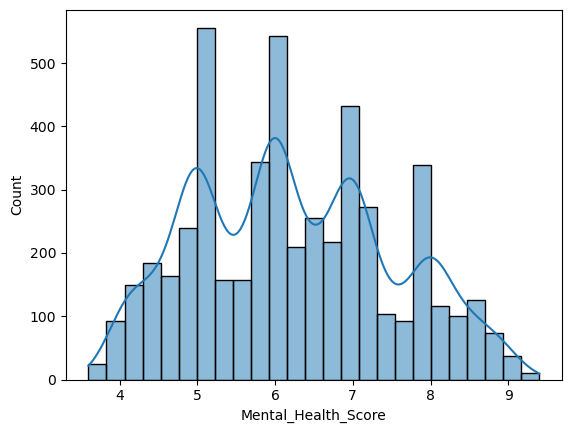

In [9]:
#checking the distribution of the Mental_Health_Score column like skewness
sns.histplot(df['Mental_Health_Score'], kde=True)

<Axes: >

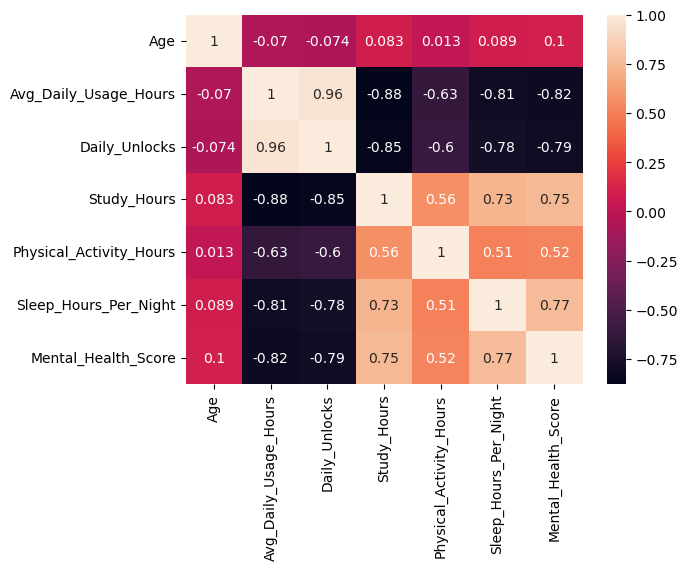

In [10]:
#checking the correlation between the columns in the DataFrame
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [11]:
#checking the unique values in the Stress_Level column
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

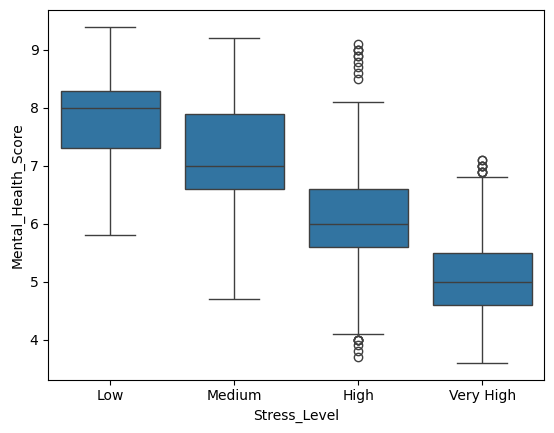

In [12]:
#creating a boxplot to visualize the relationship between Stress_Level and Mental_Health_Score
order=['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=order)

In [13]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score']

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

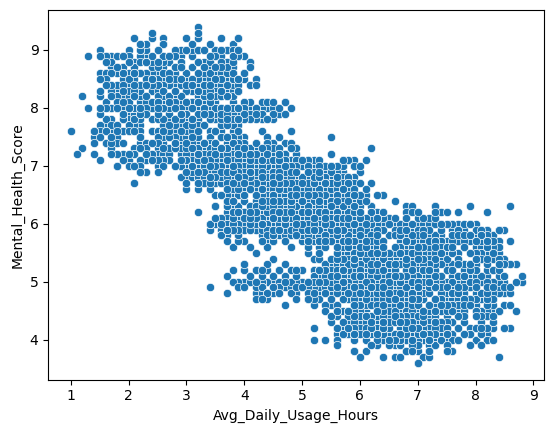

In [14]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

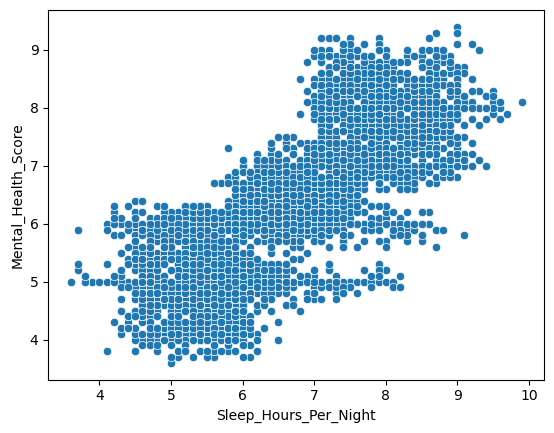

In [15]:
#checking the mental health score based on the sleep hours of the students
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df)

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

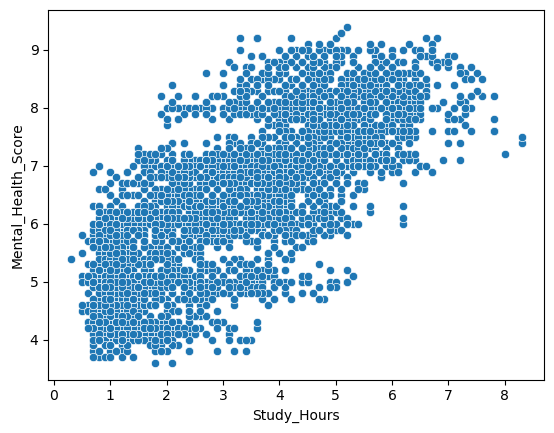

In [16]:
#checking the mental health score based on the study hours of the students
sns.scatterplot(x='Study_Hours', y='Mental_Health_Score', data=df)

In [17]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

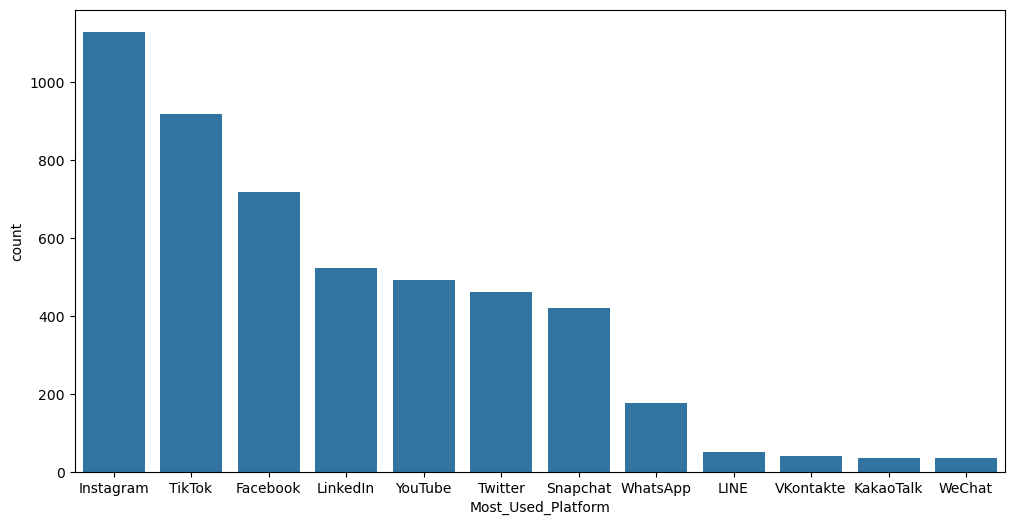

In [18]:
#checking the distribution of the Most_Used_Platform column
plt.figure(figsize=(12, 6))
sns.countplot(x=df['Most_Used_Platform'], order=df['Most_Used_Platform'].value_counts().index)

In [19]:
#checking ouliers
num_features= df.select_dtypes(include=[np.number])
Q1= num_features.quantile(0.25)
Q3= num_features.quantile(0.75)
IQR= Q3-Q1
lower_bound= Q1 - 1.5 * IQR
upper_bound= Q3 + 1.5 * IQR
outliers= ((num_features < lower_bound) | (num_features > upper_bound))
print(outliers.sum())


Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [20]:
# Clean duplicates correctly and constrain unrealistic values
df = df.drop_duplicates().copy()

df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

df.describe()


,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [21]:
#skewness checking
num_cols=df.select_dtypes(include='number')
num_cols.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [22]:
#feature engineering
top_countries =df['Country'].value_counts().index[:11].tolist()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Turkey',
 'Mexico',
 'France',
 'Spain']

In [23]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [24]:
#creating a function to group countries into a bucket and label the rest as 'Other'
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [25]:
#grouped countries because there are too many countries in the dataset and we want to focus on the top 10 countries with the highest number of respondents. This will help us to better understand the mental health impact of social media on students from these countries.
df['grouped_countries'] = df['Country'].apply(group_countries)
df['grouped_countries'].value_counts()

grouped_countries
Other        3148
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Spain          83
Name: count, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split

skewed_col = ['Study_Hours']
other_numeric_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
                      'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ordinal_cols = ['Stress_Level']
normal_cols= ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "grouped_countries"]

feature_cols = skewed_col + other_numeric_cols + ordinal_cols + normal_cols
feature_cols = [col for col in feature_cols if col in df.columns]
X = df[feature_cols]
y= df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.30, random_state=42)
       

In [27]:
#preprocesing the data using pipelines and column transformer


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
#1 skewedfeatures. handling skewed features by applying log transformation and scaling
skew_pipeline = Pipeline(steps=[('log_transformer', FunctionTransformer(np.log1p)), ('scale', StandardScaler())])

#2 other numeric features handling other numeric features by scaling
plain_numeric_pipeline = Pipeline(steps=[('scale', StandardScaler())])

#3 ordinal features maintaing order of the ordinal features by using OrdinalEncoder
#3 ordinal features maintaining order of the ordinal features by using OrdinalEncoder
ordinal_pipelone = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']], dtype=float))
])

#4 nominal features maininting only encoding of the normal features by using OneHotEncoder
nominal_pipeline= Pipeline(steps=[('encode', OneHotEncoder(handle_unknown='ignore'))])

#deciding which columns to apply which pipeline
# UPDATE THIS IN YOUR PREPROCESSING CELL:

nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('skewed', skew_pipeline, skewed_col),
        ('plain_numeric', plain_numeric_pipeline, other_numeric_cols),
        ('ordinal', ordinal_pipelone, ordinal_cols),
        ('nominal', nominal_pipeline, normal_cols)
    ],
    sparse_threshold=0
)



In [28]:
#creating a pipeline for linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', LinearRegression())])
lr_pipeline.fit(X_train, y_train)
lr_pred= lr_pipeline.predict(X_test)
lr_pred_test= lr_pipeline.predict(X_train)


lr_r2_testing= r2_score(y_test, lr_pred)
lr_r2_training= r2_score(y_train, lr_pred_test)
lr_mae = mean_absolute_error(y_test, lr_pred)


print(f"R2 score for testing data: {lr_r2_testing}")
print(f"R2 score for training data: {lr_r2_training}")
print(f"Mean Absolute Error for testing data: {lr_mae}")

R2 score for testing data: 0.7431949512902988
R2 score for training data: 0.7284451141767213
Mean Absolute Error for testing data: 0.5302565031464506


In [29]:
#creating a pipeline for random forest regressor model
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds          = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"MAE : {rf_mae}")

Accuracy of Training 0.981083601919384
Accuracy of Testing 0.8807618059364831
MAE : 0.34159073333333345


In [30]:
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Determine feature count & index of Stress_Level
X_train_trans = preprocessor.fit_transform(X_train)
total_features = X_train_trans.shape[1]

# 2. Define monotonic constraints (-1 at index 6 for Stress_Level)
monotonic_cst = np.zeros(total_features, dtype=int)
monotonic_cst[6] = -1

# 3. Create & train HistGradientBoosting Pipeline
hgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(
        monotonic_cst=monotonic_cst, 
        random_state=42
    ))
])

hgb_pipeline.fit(X_train, y_train)

# 4. Predict & Evaluate
hgb_preds = hgb_pipeline.predict(X_test)
hgb_preds_train = hgb_pipeline.predict(X_train)

print("HGB Training R²:", r2_score(y_train, hgb_preds_train))
print("HGB Testing R²:", r2_score(y_test, hgb_preds))
print("HGB Testing MAE:", mean_absolute_error(y_test, hgb_preds))

HGB Training R²: 0.9140090347854156
HGB Testing R²: 0.8511234958972795
HGB Testing MAE: 0.39459122562067356


In [31]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the hyperparameter grid
# Note: We use 'regressor__' because that is the name we gave the model in the Pipeline
param_grid_hgb = {
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_iter': [100, 200, 300, 500],
    'regressor__max_depth': [3, 5, 7, 10, None],
    'regressor__min_samples_leaf': [10, 20, 30, 50],
    'regressor__l2_regularization': [0.0, 0.1, 0.5, 1.0, 2.0]
}

# 2. Set up the Randomized Search
hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=param_grid_hgb,
    n_iter=25,         # Tests 25 random combinations
    cv=5,              # 5-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=-1          # Uses all available CPU cores
)

# 3. Fit the search to the training data
print("Tuning model... this may take a minute.")
hgb_search.fit(X_train, y_train)

# 4. Extract the best model and make predictions
best_hgb_pipeline = hgb_search.best_estimator_

hgb_best_preds = best_hgb_pipeline.predict(X_test)
hgb_best_preds_train = best_hgb_pipeline.predict(X_train)

# 5. Evaluate the optimized model
print("\n=== Tuning Results ===")
print("Best Parameters found:")
for param, value in hgb_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nOptimized HGB Training R2: {r2_score(y_train, hgb_best_preds_train):.6f}")
print(f"Optimized HGB Testing R2: {r2_score(y_test, hgb_best_preds):.6f}")
print(f"Optimized HGB Testing MAE: {mean_absolute_error(y_test, hgb_best_preds):.6f}")

Tuning model... this may take a minute.

=== Tuning Results ===
Best Parameters found:
  regressor__min_samples_leaf: 20
  regressor__max_iter: 500
  regressor__max_depth: None
  regressor__learning_rate: 0.1
  regressor__l2_regularization: 0.0

Optimized HGB Training R2: 0.981975
Optimized HGB Testing R2: 0.881428
Optimized HGB Testing MAE: 0.341296


In [32]:
# ============================================
# CONTROLLED STRESS SENSITIVITY TEST
# ============================================

stress_levels = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

# Take 100 test observations
sample = X_test.sample(
    n=min(100, len(X_test)),
    random_state=42
).copy()

results = []

for _, row in sample.iterrows():

    predictions = {}

    for stress in stress_levels:

        test_row = row.copy()

        # Change ONLY stress
        test_row["Stress_Level"] = stress

        prediction = hgb_pipeline.predict(
            pd.DataFrame([test_row])
        )[0]

        predictions[stress] = prediction

    results.append(predictions)


stress_test_df = pd.DataFrame(results)

print(stress_test_df.head(10))

        Low    Medium      High  Very High
0  6.237599  6.219029  6.219029   6.184742
1  7.866740  7.842919  7.842919   7.811038
2  4.967936  4.949365  4.949365   4.898263
3  6.420907  6.402337  6.402337   6.392402
4  6.074156  6.006353  6.006353   5.940868
5  5.975038  5.956467  5.956467   5.944701
6  8.188514  8.003727  8.003727   7.971093
7  7.600357  7.524357  7.524357   7.524357
8  5.456299  5.437729  5.437729   5.310385
9  7.692335  7.526918  7.526918   7.526918


In [33]:
# ============================================
# CHECK EXPECTED STRESS DIRECTION
# ============================================

stress_test_df["correct_order"] = (
    (stress_test_df["Low"] >= stress_test_df["Medium"]) &
    (stress_test_df["Medium"] >= stress_test_df["High"]) &
    (stress_test_df["High"] >= stress_test_df["Very High"])
)

correct = stress_test_df["correct_order"].sum()
total = len(stress_test_df)

percentage = (
    correct / total
) * 100

print(f"Correct monotonic cases: {correct}")
print(f"Total cases: {total}")
print(f"Percentage: {percentage:.2f}%")

Correct monotonic cases: 100
Total cases: 100
Percentage: 100.00%


In [34]:
# ============================================
# STRESS vs MENTAL HEALTH SCORE
# ============================================

stress_summary = (
    df.groupby("Stress_Level")["Mental_Health_Score"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median",
          Std="std",
          Min="min",
          Max="max"
      )
)

# Put stress in logical order
stress_order = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

stress_summary = stress_summary.reindex(stress_order)

stress_summary

,Count,Mean,Median,Std,Min,Max
Stress_Level,,,,,,
Low,643,7.840747,8.0,0.723625,5.8,9.4
Medium,1295,7.135907,7.0,0.916431,4.7,9.2
High,1439,6.026755,6.0,0.829129,3.7,9.1
Very High,1621,5.051326,5.0,0.663711,3.6,7.1


In [35]:
# ============================================
# STRESS vs OTHER IMPORTANT FEATURES
# ============================================

stress_features = (
    df.groupby("Stress_Level")[
        [
            "Mental_Health_Score",
            "Avg_Daily_Usage_Hours",
            "Sleep_Hours_Per_Night",
            "Daily_Unlocks",
            "Study_Hours",
            "Physical_Activity_Hours"
        ]
    ]
    .mean()
    .reindex([
        "Low",
        "Medium",
        "High",
        "Very High"
    ])
)

stress_features

,Mental_Health_Score,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Daily_Unlocks,Study_Hours,Physical_Activity_Hours
Stress_Level,,,,,,
Low,7.840747,2.774650,8.160187,113.797823,5.184759,2.349922
Medium,7.135907,3.862239,7.569575,141.014672,4.115907,2.053668
High,6.026755,5.187769,6.452328,173.963169,2.751147,1.731411
Very High,5.051326,6.866996,5.444479,216.419494,1.488711,1.289513


In [36]:
# ============================================
# STRESS-ONLY MODEL
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

stress_preprocessor = ColumnTransformer(
    transformers=[
        (
            "stress",
            OneHotEncoder(handle_unknown="ignore"),
            ["Stress_Level"]
        )
    ]
)

stress_model = Pipeline(
    steps=[
        ("preprocessor", stress_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

stress_model.fit(
    X_train[["Stress_Level"]],
    y_train
)

stress_predictions = stress_model.predict(
    X_test[["Stress_Level"]]
)

print(
    "Stress-only R²:",
    round(
        r2_score(y_test, stress_predictions),
        4
    )
)

print(
    "Stress-only MAE:",
    round(
        mean_absolute_error(y_test, stress_predictions),
        4
    )
)

Stress-only R²: 0.6547
Stress-only MAE: 0.6112


In [37]:
# ============================================
# ACTUAL MODEL PERFORMANCE BY STRESS GROUP
# ============================================

from sklearn.metrics import mean_absolute_error, r2_score

# Predictions from the FULL model
full_predictions = rf_pipeline.predict(X_test)

# Create evaluation dataframe
evaluation_df = X_test.copy()

evaluation_df["Actual_Score"] = y_test.values
evaluation_df["Predicted_Score"] = full_predictions

# Stress-wise evaluation
stress_results = []

for stress in ["Low", "Medium", "High", "Very High"]:

    group = evaluation_df[
        evaluation_df["Stress_Level"] == stress
    ]

    stress_results.append({
        "Stress_Level": stress,
        "Count": len(group),
        "Actual_Mean": group["Actual_Score"].mean(),
        "Predicted_Mean": group["Predicted_Score"].mean(),
        "MAE": mean_absolute_error(
            group["Actual_Score"],
            group["Predicted_Score"]
        )
    })

stress_results_df = pd.DataFrame(stress_results)

stress_results_df

,Stress_Level,Count,Actual_Mean,Predicted_Mean,MAE
0,Low,208,7.922596,7.874149,0.341082
1,Medium,384,7.254688,7.206678,0.371515
2,High,427,6.017799,5.984475,0.347769
3,Very High,481,5.002079,5.046881,0.312437


In [38]:
# ============================================
# CHECK PREDICTED STRESS ORDER
# ============================================

predicted_means = (
    stress_results_df
    .set_index("Stress_Level")["Predicted_Mean"]
)

print("Predicted means:")
print(predicted_means)

print("\nExpected direction:")

if (
    predicted_means["Low"]
    > predicted_means["Medium"]
    > predicted_means["High"]
    > predicted_means["Very High"]
):
    print("✅ Model preserves the expected stress direction.")

else:
    print("⚠️ Model does NOT preserve the expected stress direction.")

Predicted means:
Stress_Level
Low          7.874149
Medium       7.206678
High         5.984475
Very High    5.046881
Name: Predicted_Mean, dtype: float64

Expected direction:
✅ Model preserves the expected stress direction.


In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

random_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [40]:
random_search.best_params_

{'random forest__n_estimators': 300,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [41]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)

print(f" R2 score after hyperparameter tuning: {r2_score(y_test, rf_best_preds)}")
print(f"MAE after hyperparameter tuning: {mean_absolute_error(y_test, rf_best_preds)}")

 R2 score after hyperparameter tuning: 0.8659724882398028
MAE after hyperparameter tuning: 0.365651379189916


In [42]:
# Define missing model metrics used in the comparison table
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

rf_tuned_preds = rf_best_pipeline.predict(X_test)
rf_tuned_training_preds = rf_best_pipeline.predict(X_train)

rf_tuned_r2 = r2_score(y_test, rf_tuned_preds)
r2_tuned_training = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))

hgb_rmse = np.sqrt(mean_squared_error(y_test, hgb_preds))

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest (default)',
        'Random Forest (tuned)',
        'HistGradientBoosting (Constrained)'
    ],
    'R2': [
        lr_r2_testing,
        rf_r2_testing,
        rf_tuned_r2,
        r2_score(y_test, hgb_preds)
    ],
    'Training R2': [
        lr_r2_training,
        rf_r2_training,
        r2_tuned_training,
        r2_score(y_train, hgb_preds_train)
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        rf_tuned_mae,
        mean_absolute_error(y_test, hgb_preds)
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        rf_tuned_rmse,
        hgb_rmse
    ]
})

print(results)

                                Model        R2  Training R2       MAE  \
0                   Linear Regression  0.743195     0.728445  0.530257   
1             Random Forest (default)  0.880762     0.981084  0.341591   
2               Random Forest (tuned)  0.865972     0.952946  0.365651   
3  HistGradientBoosting (Constrained)  0.851123     0.914009  0.394591   

       RMSE  
0  0.671600  
1  0.457632  
2  0.485183  
3  0.511354  


In [43]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

perm_df

,Feature,Importance
2,Avg_Daily_Usage_Hours,0.712331
5,Sleep_Hours_Per_Night,0.254851
3,Daily_Unlocks,0.086479
11,grouped_countries,0.075306
9,Most_Used_Platform,0.065930
0,Study_Hours,0.045760
10,Purpose_Of_Use,0.037284
1,Age,0.032196
4,Physical_Activity_Hours,0.031724
6,Stress_Level,0.015023


In [44]:
import joblib

# Save the tuned, logically constrained pipeline
joblib.dump(best_hgb_pipeline, 'mental_health_model.pkl')
print("Optimized pipeline saved successfully as 'mental_health_model.pkl'")

Optimized pipeline saved successfully as 'mental_health_model.pkl'


In [ ]:
# ============================================================
# FINAL FIX: REBUILD THE PRODUCTION MODEL FROM FRESH OBJECTS
# ============================================================
# IMPORTANT:
# Run this cell AFTER loading/cleaning the dataset and after defining
# top_countries/grouped_countries. It deliberately reconstructs the
# preprocessing pipeline so no stale FunctionTransformer can be saved.

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import joblib

# 1. Exact feature definitions used by the FastAPI backend
skewed_col = ['Study_Hours']
other_numeric_cols = [
    'Age',
    'Avg_Daily_Usage_Hours',
    'Daily_Unlocks',
    'Physical_Activity_Hours',
    'Sleep_Hours_Per_Night'
]
ordinal_cols = ['Stress_Level']
normal_cols = [
    'Gender',
    'Academic_Level',
    'Most_Used_Platform',
    'Purpose_Of_Use',
    'grouped_countries'
]

feature_cols = skewed_col + other_numeric_cols + ordinal_cols + normal_cols
feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols].copy()
y = df['Mental_Health_Score'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# 2. Fresh preprocessing pipeline.
# Stress is explicitly ordinal: Low < Medium < High < Very High.
skew_pipeline_final = Pipeline(steps=[
    ('log_transformer', FunctionTransformer(np.log1p, validate=False)),
    ('scale', StandardScaler())
])

plain_numeric_pipeline_final = Pipeline(steps=[
    ('scale', StandardScaler())
])

ordinal_pipeline_final = Pipeline(steps=[
    ('encode', OrdinalEncoder(
        categories=[['Low', 'Medium', 'High', 'Very High']],
        dtype=float,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_pipeline_final = Pipeline(steps=[
    ('encode', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor_final = ColumnTransformer(
    transformers=[
        ('skewed', skew_pipeline_final, skewed_col),
        ('plain_numeric', plain_numeric_pipeline_final, other_numeric_cols),
        ('ordinal', ordinal_pipeline_final, ordinal_cols),
        ('nominal', nominal_pipeline_final, normal_cols)
    ],
    sparse_threshold=0
)

# 3. Fit preprocessing ONCE so the transformed feature count is known.
X_train_trans = preprocessor_final.fit_transform(X_train)

stress_feature_index = len(skewed_col) + len(other_numeric_cols)
total_features = X_train_trans.shape[1]

monotonic_cst = np.zeros(total_features, dtype=int)
monotonic_cst[stress_feature_index] = -1

print("Stress feature index:", stress_feature_index)
print("Total transformed features:", total_features)
print("Stress encoding:", {
    "Low": 0.0,
    "Medium": 1.0,
    "High": 2.0,
    "Very High": 3.0
})

# 4. Fresh production pipeline.
# Use the best hyperparameters found previously, but train from the NEW
# preprocessing pipeline so the saved object cannot contain stale state.
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('regressor', HistGradientBoostingRegressor(
        learning_rate=0.1,
        max_iter=500,
        max_depth=None,
        min_samples_leaf=20,
        l2_regularization=0.0,
        monotonic_cst=monotonic_cst,
        random_state=42
    ))
])

final_pipeline.fit(X_train, y_train)

test_pred = final_pipeline.predict(X_test)
train_pred = final_pipeline.predict(X_train)

print("\n=== FINAL MODEL PERFORMANCE ===")
print("Training R²:", round(r2_score(y_train, train_pred), 6))
print("Testing R² :", round(r2_score(y_test, test_pred), 6))
print("Testing MAE:", round(mean_absolute_error(y_test, test_pred), 6))

# 5. Verify the saved pipeline uses OrdinalEncoder, NOT FunctionTransformer.
saved_stress_encoder = (
    final_pipeline
    .named_steps['preprocessor']
    .named_transformers_['ordinal']
    .named_steps['encode']
)

assert isinstance(saved_stress_encoder, OrdinalEncoder)
assert list(saved_stress_encoder.categories_[0]) == [
    'Low', 'Medium', 'High', 'Very High'
]

print("\n✅ Verified: saved stress preprocessing uses OrdinalEncoder.")

# 6. Controlled stress sensitivity test.
sample = X_test.sample(n=min(100, len(X_test)), random_state=42).copy()

stress_test_results = []

for _, row in sample.iterrows():
    row_predictions = {}

    for stress in ['Low', 'Medium', 'High', 'Very High']:
        test_row = row.copy()
        test_row['Stress_Level'] = stress

        row_predictions[stress] = float(
            final_pipeline.predict(pd.DataFrame([test_row]))[0]
        )

    stress_test_results.append(row_predictions)

stress_test_df_final = pd.DataFrame(stress_test_results)

stress_test_df_final['correct_order'] = (
    (stress_test_df_final['Low'] >= stress_test_df_final['Medium']) &
    (stress_test_df_final['Medium'] >= stress_test_df_final['High']) &
    (stress_test_df_final['High'] >= stress_test_df_final['Very High'])
)

print("\n=== STRESS SENSITIVITY TEST ===")
print(stress_test_df_final[['Low', 'Medium', 'High', 'Very High']].head(10))

print(
    "\nMonotonic cases:",
    int(stress_test_df_final['correct_order'].sum()),
    "/",
    len(stress_test_df_final),
    f"({stress_test_df_final['correct_order'].mean() * 100:.2f}%)"
)

print("\nMean prediction by stress:")
print(
    stress_test_df_final[
        ['Low', 'Medium', 'High', 'Very High']
    ].mean()
)

# 7. SAVE THE CORRECTED COMPLETE PIPELINE.
joblib.dump(final_pipeline, 'mental_health_model.pkl')

print("\n✅ Corrected model saved as: mental_health_model.pkl")


Stress feature index: 6
Total transformed features: 39
Stress encoding: {'Low': 0.0, 'Medium': 1.0, 'High': 2.0, 'Very High': 3.0}

=== FINAL MODEL PERFORMANCE ===
Training R²: 0.981975
Testing R² : 0.881428
Testing MAE: 0.341296

✅ Verified: saved stress preprocessing uses OrdinalEncoder.

=== STRESS SENSITIVITY TEST ===
        Low    Medium      High  Very High
0  6.241946  6.184992  6.125467   6.083486
1  7.922032  7.898211  7.895082   7.860001
2  5.105501  5.046557  5.018566   4.920245
3  6.535504  6.478550  6.475421   6.465487
4  6.136409  6.032075  6.032075   5.966589
5  5.852051  5.794727  5.794727   5.771608
6  8.293886  8.089407  8.089407   7.990200
7  7.830508  7.720886  7.681122   7.681122
8  5.631270  5.572326  5.540349   5.413006
9  7.689089  7.518667  7.478163   7.478163

Monotonic cases: 100 / 100 (100.00%)

Mean prediction by stress:
Low          6.500729
Medium       6.416028
High         6.389441
Very High    6.322050
dtype: float64

✅ Corrected model saved as: menta

Exception ignored in: <function ResourceTracker.__del__ at 0x106b8dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102d49bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1063a9bc0>
Traceback (most recent call last